# Simulación del sistema Masa–Resorte–Amortiguador
Maria Isabel Garcia Quimbayo

## 1. Descripción del sistema

El sistema masa–resorte–amortiguador es un sistema dinámico clásico de segundo orden que describe el movimiento de una masa unida a un resorte y un amortiguador. Este tipo de sistema se utiliza ampliamente en física e ingeniería para modelar vibraciones mecánicas.

La variable de interés es el desplazamiento de la masa, denotado como $x(t)$.

## 2. Implementación en Python

Para la simulación se utilizan las librerías `NumPy`, `SciPy` y `Matplotlib`.

La función que define el sistema dinámico se implementa en una celda de código y luego se integra numéricamente usando el método de Runge–Kutta.

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

## 3. Modelo matemático

### 3.1 Ecuación diferencial de segundo orden

Aplicando la segunda ley de Newton $ \sum F = m \ddot{x}(t) $, la ecuación de movimiento del sistema es:

$ m \ddot{x}(t) + c \dot{x}(t) + k x(t) = F(t) $

donde:
- $ m $ es la masa $[Kg]$,
- $ c $ es el coeficiente de amortiguamiento $[N \cdot \frac{s}{m}]$ o $[\frac{Kg}{s}]$,
- $ k $ es la constante del resorte $[\frac{N}{m}]$,
- $ F(t) $ es una fuerza externa aplicada $[N]$.


In [ ]:

# -----------------------------
# Parámetros del sistema
# -----------------------------
m = 1.0      # masa (kg)
k = 20.0     # constante del resorte (N/m)
c = 2.0      # coeficiente de amortiguamiento (N·s/m)


# -----------------------------
# Fuerza externa
# -----------------------------
def F(t):
    return 0.0   # fuerza nula (oscilación libre)

### 3.2 Sistema de ecuaciones de primer orden

Para realizar la simulación numérica, se transforma la ecuación de segundo orden en un sistema de primer orden definiendo las variables de estado:

$ x_1 = x, \quad x_2 = \dot{x} $

El sistema dinámico resultante es:

$
\begin{cases}
\dot{x}_1 = x_2 \\
\dot{x}_2 = -\dfrac{k}{m}x_1 - \dfrac{c}{m}x_2 + \dfrac{1}{m}F(t)
\end{cases}
$

In [ ]:
# -----------------------------
# Sistema de ecuaciones
# -----------------------------
def mass_spring_damper(t, X):

    x, x_dot = X
    dxdt = x_dot
    dx_dotdt = -(k/m)*x - (c/m)*x_dot + F(t)/m

    return [dxdt, dx_dotdt]

## 4. Condiciones iniciales y parámetros

Se consideran las siguientes condiciones iniciales:

- Desplazamiento inicial: $ x(0) = 0.1 \, \text{m} $
- Velocidad inicial: $ \dot{x}(0) = 0 \, \text{m/s} $

Los parámetros del sistema se eligen de forma que el sistema sea subamortiguado.

La simulación se realiza en el intervalo temporal $𝑡 \in [0,10] $. La solución se evalúa en 1000 instantes equiespaciados con el fin de obtener una representación continua y suave de la respuesta del sistema.

In [ ]:
# -----------------------------
# Condiciones iniciales
# -----------------------------
x0 = 0.1        # desplazamiento inicial (m)
x_dot0 = 0.0    # velocidad inicial (m/s)
X0 = [x0, x_dot0]


# -----------------------------
# Intervalo de tiempo
# -----------------------------
t_span = (0, 10)                   # segundos
t_eval = np.linspace(*t_span, 1000)


# -----------------------------
# Resolución numérica
# -----------------------------
sol = solve_ivp(
    mass_spring_damper,
    t_span,
    X0,
    t_eval=t_eval,
    method='RK45'
)

## 5. Resultados

La simulación muestra una respuesta oscilatoria amortiguada, donde el desplazamiento de la masa decrece con el tiempo debido a la disipación de energía introducida por el amortiguador.

Este comportamiento es característico de los sistemas mecánicos de segundo orden con amortiguamiento viscoso.

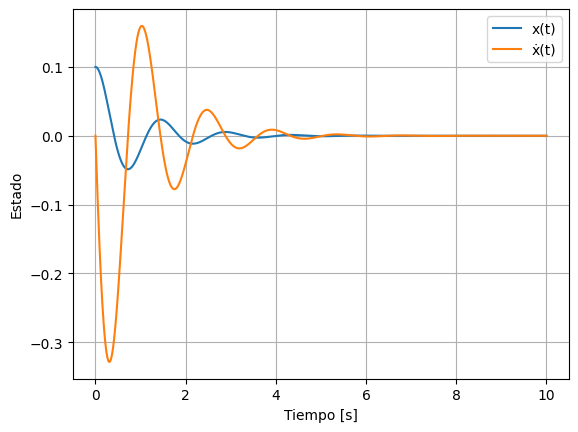

In [ ]:
# -----------------------------
# Gráficas
# -----------------------------
plt.figure()
plt.plot(sol.t, sol.y[0], label='x(t)')
plt.plot(sol.t, sol.y[1], label='ẋ(t)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Estado')
plt.legend()
plt.grid(True)
plt.show()

## Entradas del sistema masa–resorte–amortiguador

En esta sección se analizan diferentes tipos de entradas externas aplicadas al sistema masa–resorte–amortiguador, modeladas a través de la fuerza $F(t)$.

Para cada caso se estudia la respuesta temporal del desplazamiento $x(t)$:

1. Respuesta al impulso (función delta)
2. Respuesta al escalón
3. Respuesta a una entrada sinusoidal
4. Respuesta a una entrada cosenoidal

El sistema dinámico está gobernado por la ecuación:

$$
m\ddot{x}(t) + c\dot{x}(t) + kx(t) = F(t)
$$


### 1. Respuesta al impulso

La respuesta al impulso se obtiene aplicando una fuerza tipo delta de Dirac $\delta(t)$.
Numéricamente, esta función se aproxima mediante un pulso de corta duración y gran amplitud:

$$
F(t) \approx A \quad \text{para } t < \varepsilon
$$

Esta respuesta caracteriza la dinámica propia del sistema.

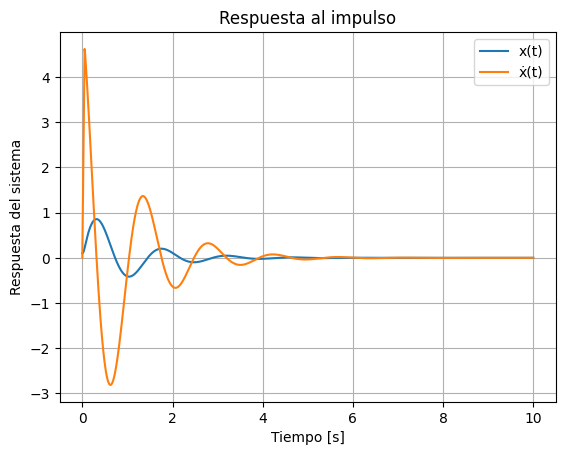

In [ ]:
def F(t):
    return 100.0 if t < 0.05 else 0.0

sol = solve_ivp(
    mass_spring_damper,
    t_span,
    X0,
    t_eval=t_eval
)

plt.figure()
plt.plot(sol.t, sol.y[0], label="x(t)")
plt.plot(sol.t, sol.y[1], label="ẋ(t)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Respuesta del sistema")
plt.title("Respuesta al impulso")
plt.legend()
plt.grid(True)
plt.show()


### 2. Respuesta al escalón

La respuesta al escalón se obtiene aplicando una fuerza constante a partir de $t=0$:

$$
F(t) = F_0
$$

Este tipo de entrada permite analizar el comportamiento transitorio y el estado estacionario del sistema.

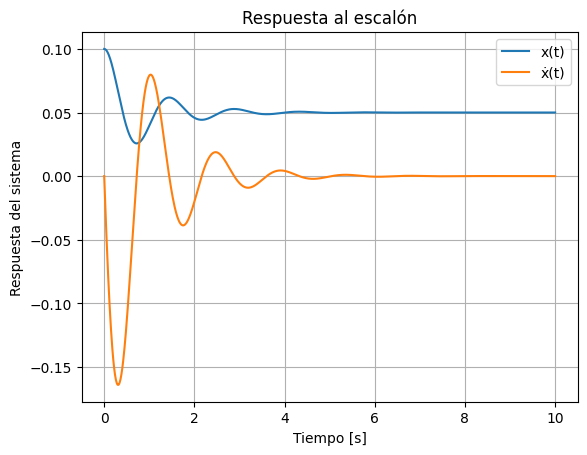

In [ ]:
def F(t):
    return 1.0

sol = solve_ivp(
    mass_spring_damper,
    t_span,
    X0,
    t_eval=t_eval
)

plt.figure()
plt.plot(sol.t, sol.y[0], label="x(t)")
plt.plot(sol.t, sol.y[1], label="ẋ(t)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Respuesta del sistema")
plt.title("Respuesta al escalón")
plt.legend()
plt.grid(True)
plt.show()

### 3. Respuesta a una entrada sinusoidal

En este caso la fuerza externa es sinusoidal:

$$
F(t) = A \sin(\omega t)
$$

Este tipo de entrada es fundamental para el análisis de resonancia y respuesta en frecuencia.


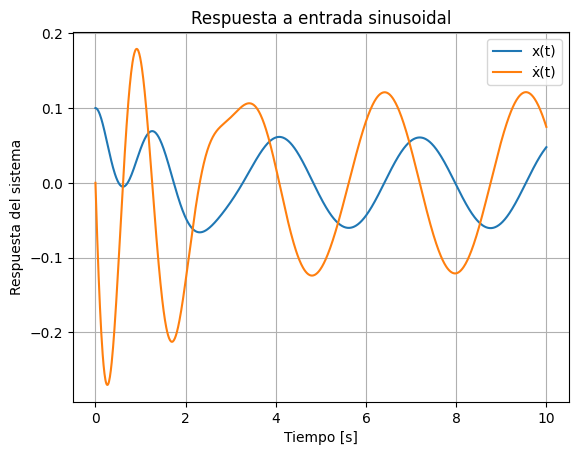

In [ ]:
A = 1.0
omega = 2.0

def F(t):
    return A * np.sin(omega * t)

sol = solve_ivp(
    mass_spring_damper,
    t_span,
    X0,
    t_eval=t_eval
)

plt.figure()
plt.plot(sol.t, sol.y[0], label="x(t)")
plt.plot(sol.t, sol.y[1], label="ẋ(t)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Respuesta del sistema")
plt.title("Respuesta a entrada sinusoidal")
plt.legend()
plt.grid(True)
plt.show()

### 4. Respuesta a una entrada cosenoidal

La entrada cosenoidal está dada por:

$$
F(t) = A \cos(\omega t)
$$

A diferencia de la entrada sinusoidal, esta fuerza inicia con un valor máximo en $t=0$.


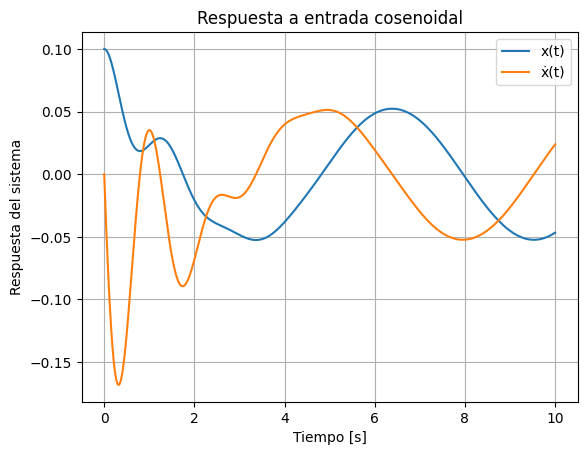

In [ ]:
A = 1.0
omega = 2.0

def F(t):
    return A * np.cos(omega * t)

sol = solve_ivp(
    mass_spring_damper,
    t_span,
    X0,
    t_eval=t_eval
)

plt.figure()
plt.plot(sol.t, sol.y[0], label="x(t)")
plt.plot(sol.t, sol.y[1], label="ẋ(t)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Respuesta del sistema")
plt.title("Respuesta a entrada cosenoidal")
plt.legend()
plt.grid(True)
plt.show()

Las diferentes respuestas obtenidas permiten analizar cómo el sistema masa–resorte–amortiguador reacciona ante distintas excitaciones externas, evidenciando comportamientos transitorios, resonantes y estacionarios característicos de sistemas dinámicos de segundo orden.

En cada simulación se muestran tanto el desplazamiento $x(t)$ como la velocidad $\dot{x}(t)$, lo que permite analizar de forma completa la evolución del estado dinámico del sistema ante distintas excitaciones externas.